<a href="https://colab.research.google.com/github/Saputoa21/Applied_ML_Spoiler_Detection_Group_Project_2025/blob/main/Kopie_von_Copy_of_Transformers_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Distilbert base cased**


## Loading the Model

In [ ]:
!pip install transformers
!pip install datasets
!pip install evaluate
# !pip install transformers torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 2.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
print(torch.__version__)

2.6.0+cu124


In [ ]:
from transformers import DistilBertTokenizer, DistilBertModel

In [ ]:
# from transformers import AutoTokenizer, AutoModelForSequenceClassification

In [ ]:
# Loading the model directly
distilbert_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-cased')

distilbert_model = DistilBertModel.from_pretrained("distilbert-base-cased")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/263M [00:00<?, ?B/s]

In [ ]:
print(distilbert_tokenizer)

DistilBertTokenizer(name_or_path='distilbert-base-cased', vocab_size=28996, model_max_length=512, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=True, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)


In [ ]:
print(distilbert_model)

DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(28996, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSdpaAttention(
          (dropout): Dropout(p=0.1, inplace=False)
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

In [ ]:
input_str = "Spoiler alert!"

input_tokens = distilbert_tokenizer.tokenize(input_str)
print(f"Tokens of the input sequence: {input_tokens}")

input_ids = distilbert_tokenizer.convert_tokens_to_ids(input_tokens)
print(f"IDs assigned to the intput sequence: {input_ids}")

decoded = distilbert_tokenizer.decode(input_ids)
print(decoded)

model_inputs = distilbert_tokenizer("Spoiler alert!", return_tensors="pt")
print(model_inputs)

Tokens of the input sequence: ['S', '##po', '##iler', 'alert', '!']
IDs assigned to the intput sequence: [156, 5674, 25614, 10427, 106]
Spoiler alert!
{'input_ids': tensor([[  101,   156,  5674, 25614, 10427,   106,   102]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1]])}


# Roberta

In [ ]:
!pip install transformers
!pip install datasets
!pip install evaluate
# !pip install transformers torch

In [ ]:
import torch
print(torch.__version__)

2.6.0+cu124


In [ ]:
from transformers import RobertaTokenizer, RobertaModel
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
model = RobertaModel.from_pretrained('roberta-base')
text = "Replace me by any text you'd like."
encoded_input = tokenizer(text, return_tensors='pt')
output = model(**encoded_input)

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

roberta_model = RobertaModel.from_pretrained('roberta-base')

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
print(roberta_tokenizer)

RobertaTokenizer(name_or_path='roberta-base', vocab_size=50265, model_max_length=512, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	50264: AddedToken("<mask>", rstrip=False, lstrip=True, single_word=False, normalized=False, special=True),
}
)


In [ ]:
print(roberta_model)

RobertaModel(
  (embeddings): RobertaEmbeddings(
    (word_embeddings): Embedding(50265, 768, padding_idx=1)
    (position_embeddings): Embedding(514, 768, padding_idx=1)
    (token_type_embeddings): Embedding(1, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): RobertaEncoder(
    (layer): ModuleList(
      (0-11): 12 x RobertaLayer(
        (attention): RobertaAttention(
          (self): RobertaSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): RobertaSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (dr

In [ ]:
input_str = "Spoiler alert!"

input_tokens = roberta_tokenizer.tokenize(input_str)
print(f"Tokens of the input sequence: {input_tokens}")

input_ids = roberta_tokenizer.convert_tokens_to_ids(input_tokens)
print(f"IDs assigned to the intput sequence: {input_ids}")

decoded = roberta_tokenizer.decode(input_ids)
print(decoded)

model_inputs = roberta_tokenizer("Spoiler alert!", return_tensors="pt")
print(model_inputs)

Tokens of the input sequence: ['Spoiler', 'Ġalert', '!']
IDs assigned to the intput sequence: [46928, 5439, 328]
Spoiler alert!
{'input_ids': tensor([[    0, 46928,  5439,   328,     2]]), 'attention_mask': tensor([[1, 1, 1, 1, 1]])}


## Loading Metrics

In [ ]:
import evaluate

accuracy_metric = evaluate.load("accuracy")
precision_metric = evaluate.load("precision")
f1_metric = evaluate.load("f1")
recall_metric = evaluate.load('recall')

matthews_metric = evaluate.load("matthews_correlation")

In [ ]:
print(accuracy_metric.description)


Accuracy is the proportion of correct predictions among the total number of cases processed. It can be computed with:
Accuracy = (TP + TN) / (TP + TN + FP + FN)
 Where:
TP: True positive
TN: True negative
FP: False positive
FN: False negative



In [ ]:
print(precision_metric.description)


Precision is the fraction of correctly labeled positive examples out of all of the examples that were labeled as positive. It is computed via the equation:
Precision = TP / (TP + FP)
where TP is the True positives (i.e. the examples correctly labeled as positive) and FP is the False positive examples (i.e. the examples incorrectly labeled as positive).



In [ ]:
print(f1_metric.description)


The F1 score is the harmonic mean of the precision and recall. It can be computed with the equation:
F1 = 2 * (precision * recall) / (precision + recall)



In [ ]:
print(recall_metric.description)


Recall is the fraction of the positive examples that were correctly labeled by the model as positive. It can be computed with the equation:
Recall = TP / (TP + FN)
Where TP is the true positives and FN is the false negatives.



In [ ]:
print(matthews_metric.description)


Compute the Matthews correlation coefficient (MCC)

The Matthews correlation coefficient is used in machine learning as a
measure of the quality of binary and multiclass classifications. It takes
into account true and false positives and negatives and is generally
regarded as a balanced measure which can be used even if the classes are of
very different sizes. The MCC is in essence a correlation coefficient value
between -1 and +1. A coefficient of +1 represents a perfect prediction, 0
an average random prediction and -1 an inverse prediction.  The statistic
is also known as the phi coefficient. [source: Wikipedia]



## Loading the dataset

In [ ]:
from datasets import load_dataset, DatasetDict, Dataset
from transformers import DataCollatorWithPadding

In [ ]:
#do so, if you mange to upload the file directly
# combined_df_exploded = load_dataset("combined_df_exploded.csv")

In [ ]:
# do so, if you have your file as zip
# import zipfile
# import os

# zip_path = "/content/combined_df_exploded.zip"
# extract_path = "/content/unzipped"

# # Create a directory to extract if it doesn't exist
# os.makedirs(extract_path, exist_ok=True)

# # Extract the ZIP file
# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_path)

# # List extracted files
# !ls /content/unzipped

In [ ]:
#do so if you have your file in google drive
import pandas as pd

csv_path = '/content/drive/MyDrive/combined_df_exploded_1.csv'  # Adjust this path
combined_df_exploded = pd.read_csv(csv_path)

# Preview the data
combined_df_exploded.head()

,review_date,movie_id,user_id,is_spoiler,review_text,rating_x,review_summary,plot_summary,duration,genre,rating_y,release_date,plot_synopsis
0,10 February 2006,tt0111161,ur1898687,True,"In its Oscar year, Shawshank Redemption (writt...",10,A classic piece of unforgettable film-making.,Chronicles the experiences of a formerly succe...,2h 22min,Crime,9.3,1994-10-14,"In 1947, Andy Dufresne (Tim Robbins), a banker..."
1,10 February 2006,tt0111161,ur1898687,True,"In its Oscar year, Shawshank Redemption (writt...",10,A classic piece of unforgettable film-making.,Chronicles the experiences of a formerly succe...,2h 22min,Drama,9.3,1994-10-14,"In 1947, Andy Dufresne (Tim Robbins), a banker..."
2,6 September 2000,tt0111161,ur0842118,True,The Shawshank Redemption is without a doubt on...,10,Simply amazing. The best film of the 90's.,Chronicles the experiences of a formerly succe...,2h 22min,Crime,9.3,1994-10-14,"In 1947, Andy Dufresne (Tim Robbins), a banker..."
3,6 September 2000,tt0111161,ur0842118,True,The Shawshank Redemption is without a doubt on...,10,Simply amazing. The best film of the 90's.,Chronicles the experiences of a formerly succe...,2h 22min,Drama,9.3,1994-10-14,"In 1947, Andy Dufresne (Tim Robbins), a banker..."
4,3 August 2001,tt0111161,ur1285640,True,I believe that this film is the best story eve...,8,The best story ever told on film,Chronicles the experiences of a formerly succe...,2h 22min,Crime,9.3,1994-10-14,"In 1947, Andy Dufresne (Tim Robbins), a banker..."


In [ ]:
#for training we need to remove unnecessary columns from the dataset
combined_df_exploded_cleaned = combined_df_exploded[['review_text', 'is_spoiler']]

combined_df_exploded_cleaned.head()

,review_text,is_spoiler
0,"In its Oscar year, Shawshank Redemption (writt...",True
1,"In its Oscar year, Shawshank Redemption (writt...",True
2,The Shawshank Redemption is without a doubt on...,True
3,The Shawshank Redemption is without a doubt on...,True
4,I believe that this film is the best story eve...,True


In [ ]:
#rename columns into 'text' and 'label'
combined_df_exploded_cleaned = combined_df_exploded_cleaned.rename(columns={'review_text': 'text', 'is_spoiler': 'label'})

#change True and False to 1 and 0
combined_df_exploded_cleaned['label'] = combined_df_exploded_cleaned['label'].astype(int)

combined_df_exploded_cleaned.head()

,text,label
0,"In its Oscar year, Shawshank Redemption (writt...",1
1,"In its Oscar year, Shawshank Redemption (writt...",1
2,The Shawshank Redemption is without a doubt on...,1
3,The Shawshank Redemption is without a doubt on...,1
4,I believe that this film is the best story eve...,1


In [ ]:
print(len(combined_df_exploded_cleaned))

42341


## Splitting the dataset

In [ ]:
# convert pandas dataframe to Hugging Face Dataset
spoiler_dataset = Dataset.from_pandas(combined_df_exploded_cleaned)

In [ ]:
print(spoiler_dataset)

Dataset({
    features: ['text', 'label'],
    num_rows: 42341
})


In [ ]:
# Just take the first 100 tokens for speed
def truncate(example):
    return {
        'text': " ".join(example['text'].split()[:100]),
        'label': example['label']
    }

In [ ]:
# Take 128 random examples for train and 32 validation
small_spoiler_dataset = DatasetDict(
    train=spoiler_dataset.shuffle(seed=24).select(range(128)).map(truncate),
    val=spoiler_dataset.shuffle(seed=24).select(range(129, 161)).map(truncate),
    test=spoiler_dataset.shuffle(seed=24).select(range(162, 194)).map(truncate))

Map:   0%|          | 0/128 [00:00<?, ? examples/s]

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

In [ ]:
print(small_spoiler_dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 128
    })
    val: Dataset({
        features: ['text', 'label'],
        num_rows: 32
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 32
    })
})


In [ ]:
small_spoiler_dataset['train'][0]

{'text': 'The film focuses on how a German named Oskar Schindler saved the lives of thousands of Jews by employing them to work in his factory during WWII. However, I feel the film\'s primary aim is not to show us Schindler\'s kindness but the horrors of war. There are some of the most true and graphic scenes here ever captured on celluloid. People being shot for no particular reason, hiding in fear, stripped and gas ed, abused......so much so that viewers watching it for the 1st time will be deeply affected. We have never got to see this "flip side" of',
 'label': 0}

In [ ]:
#def tokenize_function(examples):
#    return distilbert_tokenizer(examples["text"], padding=True, truncation=True)

In [ ]:
small_tokenized_dataset = small_spoiler_dataset.map(tokenize_function, batched=True, batch_size=16)
data_collator = DataCollatorWithPadding(tokenizer=distilbert_tokenizer)

Map:   0%|          | 0/128 [00:00<?, ? examples/s]

NameError: name 'distilbert_tokenizer' is not defined

In [ ]:
def tokenize_function(examples):
    return roberta_tokenizer(examples["text"], padding=True, truncation=True)

In [ ]:
small_tokenized_dataset = small_spoiler_dataset.map(tokenize_function, batched=True, batch_size=16)
data_collator = DataCollatorWithPadding(tokenizer=roberta_tokenizer)

Map:   0%|          | 0/128 [00:00<?, ? examples/s]

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

In [ ]:
small_tokenized_dataset['train']['text'][0]

'The film focuses on how a German named Oskar Schindler saved the lives of thousands of Jews by employing them to work in his factory during WWII. However, I feel the film\'s primary aim is not to show us Schindler\'s kindness but the horrors of war. There are some of the most true and graphic scenes here ever captured on celluloid. People being shot for no particular reason, hiding in fear, stripped and gas ed, abused......so much so that viewers watching it for the 1st time will be deeply affected. We have never got to see this "flip side" of'

In [ ]:
small_tokenized_dataset['train'][0]

{'text': 'The film focuses on how a German named Oskar Schindler saved the lives of thousands of Jews by employing them to work in his factory during WWII. However, I feel the film\'s primary aim is not to show us Schindler\'s kindness but the horrors of war. There are some of the most true and graphic scenes here ever captured on celluloid. People being shot for no particular reason, hiding in fear, stripped and gas ed, abused......so much so that viewers watching it for the 1st time will be deeply affected. We have never got to see this "flip side" of',
 'label': 0,
 'input_ids': [0,
  133,
  822,
  7235,
  15,
  141,
  10,
  1859,
  1440,
  384,
  7771,
  271,
  1811,
  2028,
  1371,
  5305,
  5,
  1074,
  9,
  1583,
  9,
  8609,
  30,
  21819,
  106,
  7,
  173,
  11,
  39,
  5566,
  148,
  29001,
  4,
  635,
  6,
  38,
  619,
  5,
  822,
  18,
  2270,
  4374,
  16,
  45,
  7,
  311,
  201,
  1811,
  2028,
  1371,
  18,
  15963,
  53,
  5,
  30178,
  9,
  997,
  4,
  345,
  32,
  1

## One-Shot Training with Pipeline from Hugging Face

### Just Classifier

In [ ]:
# pickin up one review
test_review = small_tokenized_dataset['train']['text'][0]
print(test_review)

The film focuses on how a German named Oskar Schindler saved the lives of thousands of Jews by employing them to work in his factory during WWII. However, I feel the film's primary aim is not to show us Schindler's kindness but the horrors of war. There are some of the most true and graphic scenes here ever captured on celluloid. People being shot for no particular reason, hiding in fear, stripped and gas ed, abused......so much so that viewers watching it for the 1st time will be deeply affected. We have never got to see this "flip side" of


In [ ]:
# picking up a corresponding label for the review
test_answer = small_tokenized_dataset['train']['label'][0]
print(test_answer)

0


In [ ]:
from transformers import pipeline

# Text Classification:
classifier = pipeline("text-classification")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cpu


In [ ]:
outputs = classifier(test_review)

print(outputs)

[{'label': 'POSITIVE', 'score': 0.9832897186279297}]


### With the not yet finetuned model

# Distilbert

In [ ]:
model_id = "distilbert/distilbert-base-cased"
classifier = pipeline("text-classification", model=model_id)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert/distilbert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

Device set to use cpu


In [ ]:
label_map = {'LABEL_0': 'not spoiler',
    'LABEL_1': 'spoiler'}

preds = classifier(test_review, return_all_scores=True)[0]

for pred in preds:
    pred['label'] = label_map[pred['label']]

print(preds)

/usr/local/lib/python3.11/dist-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


[{'label': 'not spoiler', 'score': 0.4642380177974701}, {'label': 'spoiler', 'score': 0.5357619524002075}]


In [ ]:
model_id = "roberta-base"
classifier = pipeline("text-classification", model=model_id)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cpu


In [ ]:
label_map = {'LABEL_0': 'not spoiler',
    'LABEL_1': 'spoiler'}

preds = classifier(test_review, return_all_scores=True)[0]

for pred in preds:
    pred['label'] = label_map[pred['label']]

print(preds)

/usr/local/lib/python3.11/dist-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


[{'label': 'not spoiler', 'score': 0.45518454909324646}, {'label': 'spoiler', 'score': 0.5448154807090759}]


## Training

In [ ]:
import numpy as np
from transformers import TrainingArguments, Trainer
from transformers import AutoModelForSequenceClassification

# distilbert_model = DistilBertModel.from_pretrained("distilbert-base-cased", num_labels=2)

distilbert_model = AutoModelForSequenceClassification.from_pretrained('distilbert/distilbert-base-cased', num_labels=2)

arguments = TrainingArguments(
    output_dir="/content/drive/MyDrive/Colab Notebooks/sample_cl_trainer", #change it if you want to store models somewhere else
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    logging_steps=8,
    num_train_epochs=10,
    eval_strategy="epoch", # run validation at the end of each epoch
    save_strategy="epoch",
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    report_to='none',
    seed=224
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"],
        "precision": precision_metric.compute(predictions=predictions, references=labels)["precision"],
        "recall": recall_metric.compute(predictions=predictions, references=labels)["recall"],
        "f1": f1_metric.compute(predictions=predictions, references=labels)["f1"],
        "matthews_correlation": matthews_metric.compute(predictions=predictions, references=labels)["matthews_correlation"]}


trainer = Trainer(
    model=roberta_model,
    args=arguments,
    train_dataset=small_tokenized_dataset['train'],
    eval_dataset=small_tokenized_dataset['val'], #change to test for final step
    tokenizer=roberta_tokenizer,  # Optional, only if needed
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert/distilbert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-56-f6df2af154f6>:35: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.train()

TypeError: RobertaModel.forward() got an unexpected keyword argument 'labels'

In [ ]:
#storing tranining values for illustration
train_history = trainer.state.log_history

epochs = []
train_losses = []

for entry in train_history:
    if 'epoch' in entry and 'loss' in entry:
        epochs.append(entry['epoch'])
        train_losses.append(entry['loss'])

In [ ]:
print(train_history)

[{'loss': 0.6352, 'grad_norm': 1.3568943738937378, 'learning_rate': 1.825e-05, 'epoch': 1.0, 'step': 8}, {'eval_loss': 0.55326247215271, 'eval_accuracy': 0.78125, 'eval_precision': 0.0, 'eval_recall': 0.0, 'eval_f1': 0.0, 'eval_matthews_correlation': 0.0, 'eval_runtime': 6.9454, 'eval_samples_per_second': 4.607, 'eval_steps_per_second': 0.288, 'epoch': 1.0, 'step': 8}, {'loss': 0.591, 'grad_norm': 1.575698971748352, 'learning_rate': 1.6250000000000002e-05, 'epoch': 2.0, 'step': 16}, {'eval_loss': 0.5275901556015015, 'eval_accuracy': 0.78125, 'eval_precision': 0.0, 'eval_recall': 0.0, 'eval_f1': 0.0, 'eval_matthews_correlation': 0.0, 'eval_runtime': 8.6507, 'eval_samples_per_second': 3.699, 'eval_steps_per_second': 0.231, 'epoch': 2.0, 'step': 16}, {'loss': 0.5871, 'grad_norm': 2.564258337020874, 'learning_rate': 1.425e-05, 'epoch': 3.0, 'step': 24}, {'eval_loss': 0.5175715684890747, 'eval_accuracy': 0.78125, 'eval_precision': 0.0, 'eval_recall': 0.0, 'eval_f1': 0.0, 'eval_matthews_corr

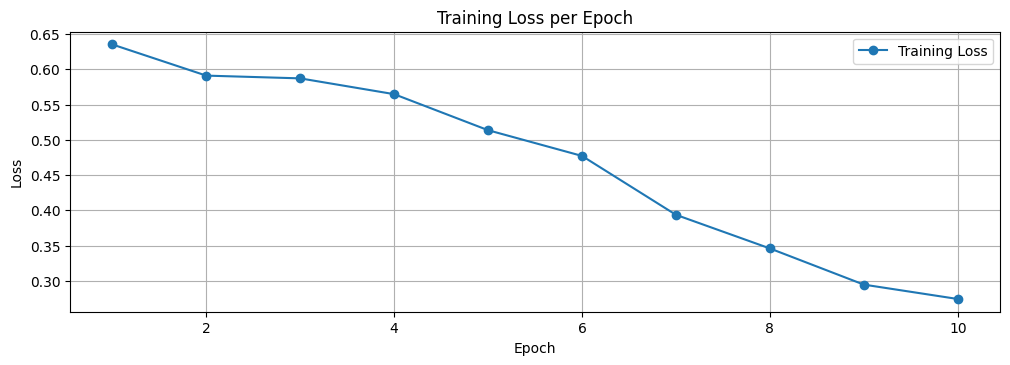

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# Loss Plot
plt.subplot(2, 1, 1)
plt.plot(epochs, train_losses, marker='o', label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss per Epoch')
plt.grid(True)
plt.legend()

In [ ]:
# to see if the models predics always 0

from collections import Counter
preds = trainer.predict(small_tokenized_dataset['val']).predictions
pred_labels = preds.argmax(axis=1)
print(Counter(pred_labels))  # Count predicted classes

true_labels = small_tokenized_dataset['val']['label']
print(Counter(true_labels))  # Count actual classes

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Counter({np.int64(0): 32})
Counter({0: 25, 1: 7})


In [ ]:
from collections import Counter
import numpy as np

# Get predictions
preds = trainer.predict(small_tokenized_dataset['val']).predictions
pred_labels = np.argmax(preds, axis=1)

# Count how many of each label are predicted
print("Predicted label counts:", Counter(pred_labels))

# Compare with ground truth
true_labels = small_tokenized_dataset['val']['label']
print("True label counts:", Counter(true_labels))

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Predicted label counts: Counter({np.int64(0): 32})
True label counts: Counter({0: 25, 1: 7})


<Axes: >

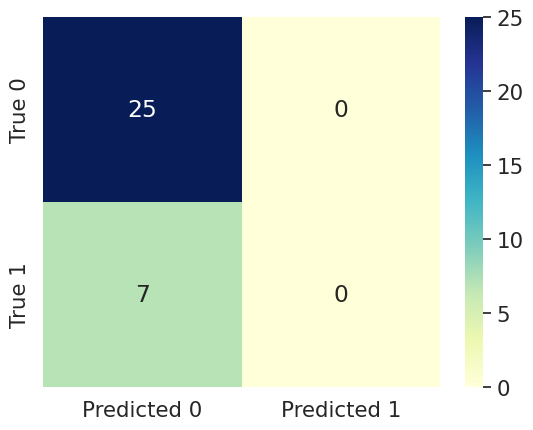

In [ ]:
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sn

conf_mat = metrics.confusion_matrix(true_labels, pred_labels)
df_cm = pd.DataFrame(conf_mat, ["True 0","True 1"], ["Predicted 0","Predicted 1"])

sn.set(font_scale=1.4)
sn.heatmap(df_cm, annot=True, fmt='d', cmap="YlGnBu")

# Roberta

In [ ]:
import numpy as np
from transformers import TrainingArguments, Trainer
from transformers import AutoModelForSequenceClassification

roberta_model = AutoModelForSequenceClassification.from_pretrained('roberta-base', num_labels=2)

arguments = TrainingArguments(
    output_dir="/content/drive/MyDrive/Colab Notebooks/sample_cl_trainer", #change it if you want to store models somewhere else
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    logging_steps=8,
    num_train_epochs=5,
    eval_strategy="epoch", # run validation at the end of each epoch
    save_strategy="epoch",
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    report_to='none',
    seed=224
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"],
        "precision": precision_metric.compute(predictions=predictions, references=labels)["precision"],
        "recall": recall_metric.compute(predictions=predictions, references=labels)["recall"],
        "f1": f1_metric.compute(predictions=predictions, references=labels)["f1"],
        "matthews_correlation": matthews_metric.compute(predictions=predictions, references=labels)["matthews_correlation"]}


trainer = Trainer(
    model=roberta_model,
    args=arguments,
    train_dataset=small_tokenized_dataset['train'],
    eval_dataset=small_tokenized_dataset['val'], #change to test for final step
    tokenizer=roberta_tokenizer,  # Optional, only if needed
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-57-4cf5bf0ac325>:33: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Matthews Correlation
1,0.654900,0.616316,0.718750,0.000000,0.000000,0.000000,0.000000
2,0.618200,0.603759,0.718750,0.000000,0.000000,0.000000,0.000000
3,0.600000,0.611602,0.718750,0.000000,0.000000,0.000000,0.000000
4,0.571400,0.618700,0.718750,0.000000,0.000000,0.000000,0.000000
5,0.569000,0.621976,0.718750,0.000000,0.000000,0.000000,0.000000


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.p

TrainOutput(global_step=40, training_loss=0.6026908159255981, metrics={'train_runtime': 1970.8204, 'train_samples_per_second': 0.325, 'train_steps_per_second': 0.02, 'total_flos': 51816433464960.0, 'train_loss': 0.6026908159255981, 'epoch': 5.0})

In [ ]:
from collections import Counter
preds = trainer.predict(small_tokenized_dataset['val']).predictions
pred_labels = preds.argmax(axis=1)
print(Counter(pred_labels))  # Count predicted classes

true_labels = small_tokenized_dataset['val']['label']
print(Counter(true_labels))  # Count actual classes

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Counter({np.int64(0): 32})
Counter({0: 23, 1: 9})


In [ ]:
import numpy as np

# Get predictions
preds = trainer.predict(small_tokenized_dataset['val']).predictions
pred_labels = np.argmax(preds, axis=1)

# Count how many of each label are predicted
print("Predicted label counts:", Counter(pred_labels))

# Compare with ground truth
true_labels = small_tokenized_dataset['val']['label']
print("True label counts:", Counter(true_labels))

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Predicted label counts: Counter({np.int64(0): 32})
True label counts: Counter({0: 23, 1: 9})


<Axes: >

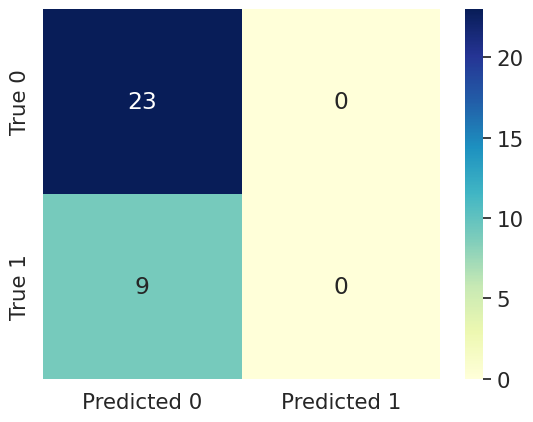

In [ ]:
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sn

conf_mat = metrics.confusion_matrix(true_labels, pred_labels)
df_cm = pd.DataFrame(conf_mat, ["True 0","True 1"], ["Predicted 0","Predicted 1"])

sn.set(font_scale=1.4)
sn.heatmap(df_cm, annot=True, fmt='d', cmap="YlGnBu")

## Testing

In [ ]:
fine_tuned_model = AutoModelForSequenceClassification.from_pretrained("/content/drive/MyDrive/Colab Notebooks/sample_cl_trainer/checkpoint-48")
#I chose this model as it had the minimal training loss

One review

In [ ]:
model_inputs = distilbert_tokenizer(test_review, return_tensors="pt")
prediction = torch.argmax(fine_tuned_model(**model_inputs).logits)

print(["Non-Spoiler", "Spoiler"][prediction])

NameError: name 'distilbert_tokenizer' is not defined

In [ ]:
import torch
model_inputs = roberta_tokenizer(test_review, return_tensors="pt")
prediction = torch.argmax(fine_tuned_model(**model_inputs).logits)

print(["Non-Spoiler", "Spoiler"][prediction])

NameError: name 'test_review' is not defined

Test set

In [ ]:
trainer = Trainer(
    model=fine_tuned_model,
    args=arguments,
    train_dataset=small_tokenized_dataset['train'],
    eval_dataset=small_tokenized_dataset['test'], #change to test for final step
    tokenizer=distilbert_tokenizer,  # Optional, only if needed
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

NameError: name 'distilbert_tokenizer' is not defined

In [ ]:
trainer = Trainer(
    model=fine_tuned_model,
    args=arguments,
    train_dataset=small_tokenized_dataset['train'],
    eval_dataset=small_tokenized_dataset['test'], #change to test for final step
    tokenizer=roberta_tokenizer,  # Optional, only if needed
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

<ipython-input-69-02216cda4881>:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.evaluate(eval_dataset=small_tokenized_dataset['test'])

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


{'eval_loss': 0.519122838973999,
 'eval_model_preparation_time': 0.0039,
 'eval_accuracy': 0.78125,
 'eval_precision': 0.0,
 'eval_recall': 0.0,
 'eval_f1': 0.0,
 'eval_matthews_correlation': 0.0,
 'eval_runtime': 39.6408,
 'eval_samples_per_second': 0.807,
 'eval_steps_per_second': 0.05}

# Balancing the dataset

In [ ]:
#we do this in order to balance the dataset (so that we don't have too many 0 class examples)

import pandas as pd
from datasets import Dataset, DatasetDict

df = combined_df_exploded_cleaned.copy()

def truncate_text(text):
    return " ".join(text.split()[:100])
df["text"] = df["text"].apply(truncate_text)

# 128 for each class in the rain set
label_0 = df[df["label"] == 0].sample(n=64, random_state=42)
label_1 = df[df["label"] == 1].sample(n=64, random_state=42)
train_df = pd.concat([label_0, label_1]).sample(frac=1, random_state=42)

# 32 for val and test
label_0_rest = df[df["label"] == 0].drop(label_0.index)
label_1_rest = df[df["label"] == 1].drop(label_1.index)
val_df = pd.concat([
    label_0_rest.sample(n=16, random_state=43),
    label_1_rest.sample(n=16, random_state=43)
]).sample(frac=1, random_state=43)
test_df = pd.concat([
    label_0_rest.drop(val_df[val_df["label"] == 0].index).sample(n=16, random_state=44),
    label_1_rest.drop(val_df[val_df["label"] == 1].index).sample(n=16, random_state=44)
]).sample(frac=1, random_state=44)

small_spoiler_dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df.reset_index(drop=True)),
    "val": Dataset.from_pandas(val_df.reset_index(drop=True)),
    "test": Dataset.from_pandas(test_df.reset_index(drop=True)),
})

In [ ]:
### DISTILBERT ###

small_tokenized_dataset = small_spoiler_dataset.map(tokenize_function, batched=True, batch_size=16)
data_collator = DataCollatorWithPadding(tokenizer=distilbert_tokenizer)

Map:   0%|          | 0/128 [00:00<?, ? examples/s]

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

NameError: name 'distilbert_tokenizer' is not defined

In [ ]:
### ROBERTA ###

small_tokenized_dataset = small_spoiler_dataset.map(tokenize_function, batched=True, batch_size=16)
data_collator = DataCollatorWithPadding(tokenizer=roberta_tokenizer)

Map:   0%|          | 0/128 [00:00<?, ? examples/s]

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

In [ ]:
small_tokenized_dataset['train']['text'][0]

'I just saw the movie it was great, the symbolism, the actors everything and everyone in that movie were brilliant. It maybe an "old" movie, doesn\'t have special effects and stuff but i enjoyed every second of that movie. In two words brilliant and magnificent (I cant describe it in one word).It is about a man who never give up in what life throws at him, but this is a little bit common. So what is that keeps "awake" on an almost 3 hour movie? Is the way that the movie flows, the dialogs, humor and the mystery that keeps'

In [ ]:
small_tokenized_dataset['train'][0]

{'text': 'I just saw the movie it was great, the symbolism, the actors everything and everyone in that movie were brilliant. It maybe an "old" movie, doesn\'t have special effects and stuff but i enjoyed every second of that movie. In two words brilliant and magnificent (I cant describe it in one word).It is about a man who never give up in what life throws at him, but this is a little bit common. So what is that keeps "awake" on an almost 3 hour movie? Is the way that the movie flows, the dialogs, humor and the mystery that keeps',
 'label': 0,
 'input_ids': [0,
  100,
  95,
  794,
  5,
  1569,
  24,
  21,
  372,
  6,
  5,
  37107,
  6,
  5,
  5552,
  960,
  8,
  961,
  11,
  14,
  1569,
  58,
  6967,
  4,
  85,
  2085,
  41,
  22,
  279,
  113,
  1569,
  6,
  630,
  75,
  33,
  780,
  3038,
  8,
  2682,
  53,
  939,
  3776,
  358,
  200,
  9,
  14,
  1569,
  4,
  96,
  80,
  1617,
  6967,
  8,
  19243,
  36,
  100,
  17672,
  6190,
  24,
  11,
  65,
  2136,
  322,
  243,
  16,
  59,


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# we add weights to improve the results
labels = small_tokenized_dataset['train']['label']
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(labels), y=labels)
class_weights = torch.tensor(class_weights, dtype=torch.float)
print(class_weights)

tensor([1., 1.])


In [ ]:
from transformers import Trainer

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        global class_weights
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights.to(model.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

# Distilbert

In [ ]:
import numpy as np
from transformers import TrainingArguments, Trainer
from transformers import AutoModelForSequenceClassification

# distilbert_model = DistilBertModel.from_pretrained("distilbert-base-cased", num_labels=2)

distilbert_model = AutoModelForSequenceClassification.from_pretrained('distilbert/distilbert-base-cased', num_labels=2)

arguments = TrainingArguments(
    output_dir="/content/drive/MyDrive/Colab Notebooks/sample_cl_trainer_balanced", #change it if you want to store models somewhere else
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    logging_steps=8,
    num_train_epochs=10,
    eval_strategy="epoch", # run validation at the end of each epoch
    save_strategy="epoch",
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    report_to='none',
    seed=224
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"],
        "precision": precision_metric.compute(predictions=predictions, references=labels)["precision"],
        "recall": recall_metric.compute(predictions=predictions, references=labels)["recall"],
        "f1": f1_metric.compute(predictions=predictions, references=labels)["f1"],
        "matthews_correlation": matthews_metric.compute(predictions=predictions, references=labels)["matthews_correlation"]}


trainer = Trainer(
    model=distilbert_model,
    args=arguments,
    train_dataset=small_tokenized_dataset['train'],
    eval_dataset=small_tokenized_dataset['val'], #change to test for final step
    tokenizer=distilbert_tokenizer,  # Optional, only if needed
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert/distilbert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-55-60847d2f9865>:35: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Matthews Correlation
1,0.706800,0.690235,0.625000,0.600000,0.750000,0.666667,0.258199
2,0.680000,0.687823,0.687500,0.650000,0.812500,0.722222,0.387298
3,0.670000,0.685138,0.625000,0.590909,0.812500,0.684211,0.269680
4,0.641700,0.679922,0.625000,0.666667,0.500000,0.571429,0.258199
5,0.599200,0.670074,0.625000,0.625000,0.625000,0.625000,0.250000
6,0.530200,0.667818,0.625000,0.666667,0.500000,0.571429,0.258199
7,0.449100,0.668185,0.656250,0.631579,0.750000,0.685714,0.318142
8,0.366800,0.671739,0.625000,0.642857,0.562500,0.600000,0.251976
9,0.325800,0.680314,0.625000,0.611111,0.687500,0.647059,0.251976
10,0.295400,0.682902,0.625000,0.611111,0.687500,0.647059,0.251976


TrainOutput(global_step=80, training_loss=0.5264985114336014, metrics={'train_runtime': 1672.2332, 'train_samples_per_second': 0.765, 'train_steps_per_second': 0.048, 'total_flos': 61398639277056.0, 'train_loss': 0.5264985114336014, 'epoch': 10.0})

In [ ]:
#storing tranining values for illustration
train_history = trainer.state.log_history

epochs = []
train_losses = []

for entry in train_history:
    if 'epoch' in entry and 'loss' in entry:
        epochs.append(entry['epoch'])
        train_losses.append(entry['loss'])

In [ ]:
print(train_history)

[{'loss': 0.7068, 'grad_norm': 1.0951324701309204, 'learning_rate': 1.825e-05, 'epoch': 1.0, 'step': 8}, {'eval_loss': 0.6902351379394531, 'eval_accuracy': 0.625, 'eval_precision': 0.6, 'eval_recall': 0.75, 'eval_f1': 0.6666666666666666, 'eval_matthews_correlation': 0.2581988897471611, 'eval_runtime': 15.0811, 'eval_samples_per_second': 2.122, 'eval_steps_per_second': 0.133, 'epoch': 1.0, 'step': 8}, {'loss': 0.68, 'grad_norm': 1.4337472915649414, 'learning_rate': 1.6250000000000002e-05, 'epoch': 2.0, 'step': 16}, {'eval_loss': 0.6878230571746826, 'eval_accuracy': 0.6875, 'eval_precision': 0.65, 'eval_recall': 0.8125, 'eval_f1': 0.7222222222222222, 'eval_matthews_correlation': 0.3872983346207417, 'eval_runtime': 10.8758, 'eval_samples_per_second': 2.942, 'eval_steps_per_second': 0.184, 'epoch': 2.0, 'step': 16}, {'loss': 0.67, 'grad_norm': 2.786942958831787, 'learning_rate': 1.425e-05, 'epoch': 3.0, 'step': 24}, {'eval_loss': 0.6851376295089722, 'eval_accuracy': 0.625, 'eval_precision'

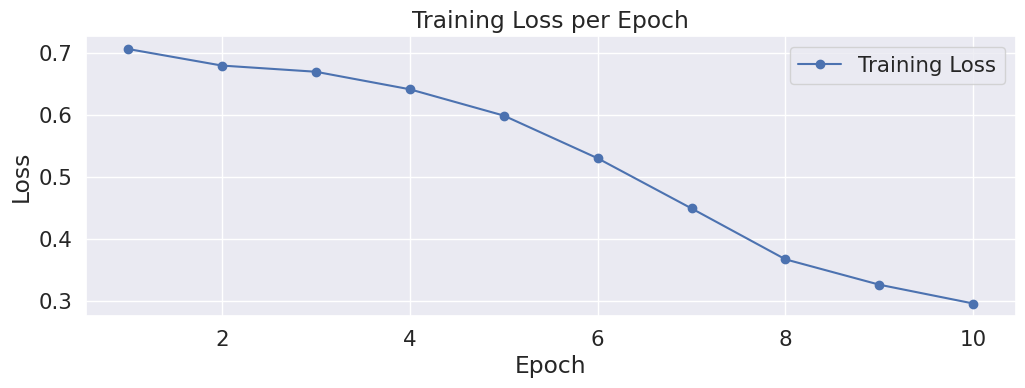

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# Loss Plot
plt.subplot(2, 1, 1)
plt.plot(epochs, train_losses, marker='o', label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss per Epoch')
plt.grid(True)
plt.legend()

In [ ]:
# to see if the models predicts always 0

from collections import Counter
preds = trainer.predict(small_tokenized_dataset['val']).predictions
pred_labels = preds.argmax(axis=1)
print(Counter(pred_labels))  # Count predicted classes

true_labels = small_tokenized_dataset['val']['label']
print(Counter(true_labels))  # Count actual classes

Counter({np.int64(0): 20, np.int64(1): 12})
Counter({1: 16, 0: 16})


In [ ]:
from collections import Counter
import numpy as np

# Get predictions
preds = trainer.predict(small_tokenized_dataset['val']).predictions
pred_labels = np.argmax(preds, axis=1)

# Count how many of each label are predicted
print("Predicted label counts:", Counter(pred_labels))

# Compare with ground truth
true_labels = small_tokenized_dataset['val']['label']
print("True label counts:", Counter(true_labels))

Predicted label counts: Counter({np.int64(0): 20, np.int64(1): 12})
True label counts: Counter({1: 16, 0: 16})


<Axes: >

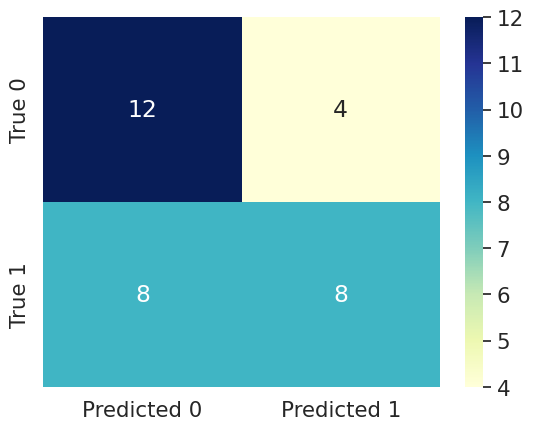

In [ ]:
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sn

conf_mat = metrics.confusion_matrix(true_labels, pred_labels)
df_cm = pd.DataFrame(conf_mat, ["True 0","True 1"], ["Predicted 0","Predicted 1"])

sn.set(font_scale=1.4)
sn.heatmap(df_cm, annot=True, fmt='d', cmap="YlGnBu")

In [ ]:
fine_tuned_model = AutoModelForSequenceClassification.from_pretrained("/content/drive/MyDrive/Colab Notebooks/sample_cl_trainer_balanced/checkpoint-56") #choose the best one

In [ ]:
model_inputs = distilbert_tokenizer(test_review, return_tensors="pt")
prediction = torch.argmax(fine_tuned_model(**model_inputs).logits)

print(["Non-Spoiler", "Spoiler"][prediction])

Non-Spoiler


In [ ]:
trainer = Trainer(
    model=fine_tuned_model,
    args=arguments,
    train_dataset=small_tokenized_dataset['train'],
    eval_dataset=small_tokenized_dataset['test'], #change to test for final step
    tokenizer=distilbert_tokenizer,  # Optional, only if needed
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

<ipython-input-68-221a61a70341>:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.evaluate(eval_dataset=small_tokenized_dataset['test'])

{'eval_loss': 0.6568019986152649,
 'eval_model_preparation_time': 0.0018,
 'eval_accuracy': 0.5625,
 'eval_precision': 0.5454545454545454,
 'eval_recall': 0.75,
 'eval_f1': 0.631578947368421,
 'eval_matthews_correlation': 0.13483997249264842,
 'eval_runtime': 10.1669,
 'eval_samples_per_second': 3.147,
 'eval_steps_per_second': 0.197}

# Roberta

In [ ]:
import numpy as np
from transformers import TrainingArguments, Trainer
from transformers import AutoModelForSequenceClassification


roberta_model = AutoModelForSequenceClassification.from_pretrained('roberta-base', num_labels=2)
arguments = TrainingArguments(
    output_dir="/content/drive/MyDrive/Colab Notebooks/sample_cl_trainer_balanced", #change it if you want to store models somewhere else
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    logging_steps=8,
    num_train_epochs=5,
    eval_strategy="epoch", # run validation at the end of each epoch
    save_strategy="epoch",
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    report_to='none',
    seed=224
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"],
        "precision": precision_metric.compute(predictions=predictions, references=labels)["precision"],
        "recall": recall_metric.compute(predictions=predictions, references=labels)["recall"],
        "f1": f1_metric.compute(predictions=predictions, references=labels)["f1"],
        "matthews_correlation": matthews_metric.compute(predictions=predictions, references=labels)["matthews_correlation"]}


trainer = Trainer(
    model=roberta_model,
    args=arguments,
    train_dataset=small_tokenized_dataset['train'],
    eval_dataset=small_tokenized_dataset['val'], #change to test for final step
    tokenizer=roberta_tokenizer,  # Optional, only if needed
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-79-3e991525dbd2>:33: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Matthews Correlation
1,0.700600,0.691957,0.500000,0.500000,1.000000,0.666667,0.000000
2,0.684200,0.689945,0.593750,0.666667,0.375000,0.480000,0.208514
3,0.686800,0.688122,0.718750,0.769231,0.625000,0.689655,0.445399
4,0.684900,0.686420,0.625000,0.611111,0.687500,0.647059,0.251976
5,0.682500,0.685568,0.656250,0.608696,0.875000,0.717949,0.347524


TrainOutput(global_step=40, training_loss=0.6878119945526123, metrics={'train_runtime': 1437.7573, 'train_samples_per_second': 0.445, 'train_steps_per_second': 0.028, 'total_flos': 49662211699200.0, 'train_loss': 0.6878119945526123, 'epoch': 5.0})

In [ ]:
# to se if the models predics always 0

from collections import Counter
preds = trainer.predict(small_tokenized_dataset['val']).predictions
pred_labels = preds.argmax(axis=1)
print(Counter(pred_labels))  # Count predicted classes

true_labels = small_tokenized_dataset['val']['label']
print(Counter(true_labels))  # Count actual classes

Counter({np.int64(1): 23, np.int64(0): 9})
Counter({1: 16, 0: 16})


In [ ]:
from collections import Counter
import numpy as np

# Get predictions
preds = trainer.predict(small_tokenized_dataset['val']).predictions
pred_labels = np.argmax(preds, axis=1)

# Count how many of each label are predicted
print("Predicted label counts:", Counter(pred_labels))

# Compare with ground truth
true_labels = small_tokenized_dataset['val']['label']
print("True label counts:", Counter(true_labels))

Predicted label counts: Counter({np.int64(1): 23, np.int64(0): 9})
True label counts: Counter({1: 16, 0: 16})


<Axes: >

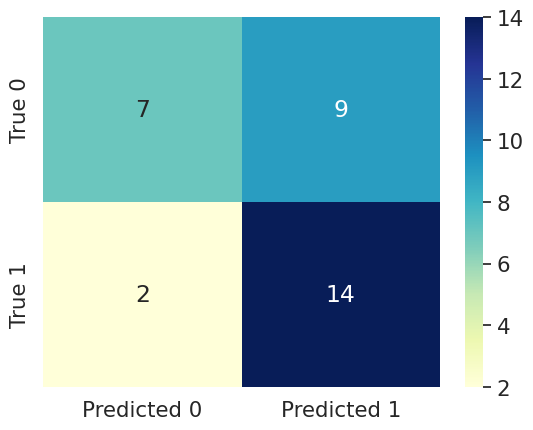

In [ ]:
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sn

conf_mat = metrics.confusion_matrix(true_labels, pred_labels)
df_cm = pd.DataFrame(conf_mat, ["True 0","True 1"], ["Predicted 0","Predicted 1"])

sn.set(font_scale=1.4)
sn.heatmap(df_cm, annot=True, fmt='d', cmap="YlGnBu")

In [ ]:
#choose the best checkpoint
fine_tuned_model = AutoModelForSequenceClassification.from_pretrained("/content/drive/MyDrive/Colab Notebooks/sample_cl_trainer_balanced/checkpoint-16")

In [92]:
test_review = small_tokenized_dataset['train']['text'][0]
model_inputs = roberta_tokenizer(test_review, return_tensors="pt")
prediction = torch.argmax(fine_tuned_model(**model_inputs).logits)

print(["Non-Spoiler", "Spoiler"][prediction])

Non-Spoiler


In [93]:
trainer = Trainer(
    model=fine_tuned_model,
    args=arguments,
    train_dataset=small_tokenized_dataset['train'],
    eval_dataset=small_tokenized_dataset['test'], #change to test for final step
    #tokenizer=distilbert_tokenizer,  # Optional, only if needed
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [94]:
trainer.evaluate(eval_dataset=small_tokenized_dataset['test'])

{'eval_loss': 0.6934090256690979,
 'eval_model_preparation_time': 0.004,
 'eval_accuracy': 0.5,
 'eval_precision': 0.5,
 'eval_recall': 0.25,
 'eval_f1': 0.3333333333333333,
 'eval_matthews_correlation': 0.0,
 'eval_runtime': 14.7724,
 'eval_samples_per_second': 2.166,
 'eval_steps_per_second': 0.135}

# Finetuning with more samples

In [95]:
#we do this in order to balance the dataset (so that we don't have too many 0 class examples)

import pandas as pd
from datasets import Dataset, DatasetDict

df = combined_df_exploded_cleaned.copy()

def truncate_text(text):
    return " ".join(text.split()[:100])
df["text"] = df["text"].apply(truncate_text)

# 64 for each class
label_0 = df[df["label"] == 0].sample(n=64, random_state=42)
label_1 = df[df["label"] == 1].sample(n=64, random_state=42)
train_df = pd.concat([label_0, label_1]).sample(frac=1, random_state=42)

# 16 for val and test
label_0_rest = df[df["label"] == 0].drop(label_0.index)
label_1_rest = df[df["label"] == 1].drop(label_1.index)
val_df = pd.concat([
    label_0_rest.sample(n=32, random_state=43),
    label_1_rest.sample(n=32, random_state=43)
]).sample(frac=1, random_state=43)
test_df = pd.concat([
    label_0_rest.drop(val_df[val_df["label"] == 0].index).sample(n=32, random_state=44),
    label_1_rest.drop(val_df[val_df["label"] == 1].index).sample(n=32, random_state=44)
]).sample(frac=1, random_state=44)

small_spoiler_dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df.reset_index(drop=True)),
    "val": Dataset.from_pandas(val_df.reset_index(drop=True)),
    "test": Dataset.from_pandas(test_df.reset_index(drop=True)),
})

In [96]:
small_tokenized_dataset = small_spoiler_dataset.map(tokenize_function, batched=True, batch_size=16)
data_collator = DataCollatorWithPadding(tokenizer=distilbert_tokenizer)

Map:   0%|          | 0/128 [00:00<?, ? examples/s]

Map:   0%|          | 0/64 [00:00<?, ? examples/s]

Map:   0%|          | 0/64 [00:00<?, ? examples/s]

NameError: name 'distilbert_tokenizer' is not defined

In [97]:
small_tokenized_dataset = small_spoiler_dataset.map(tokenize_function, batched=True, batch_size=16)
data_collator = DataCollatorWithPadding(tokenizer=roberta_tokenizer)

Map:   0%|          | 0/128 [00:00<?, ? examples/s]

Map:   0%|          | 0/64 [00:00<?, ? examples/s]

Map:   0%|          | 0/64 [00:00<?, ? examples/s]

In [98]:
small_tokenized_dataset['train']['text'][0]

'I just saw the movie it was great, the symbolism, the actors everything and everyone in that movie were brilliant. It maybe an "old" movie, doesn\'t have special effects and stuff but i enjoyed every second of that movie. In two words brilliant and magnificent (I cant describe it in one word).It is about a man who never give up in what life throws at him, but this is a little bit common. So what is that keeps "awake" on an almost 3 hour movie? Is the way that the movie flows, the dialogs, humor and the mystery that keeps'

In [99]:
small_tokenized_dataset['train'][0]

{'text': 'I just saw the movie it was great, the symbolism, the actors everything and everyone in that movie were brilliant. It maybe an "old" movie, doesn\'t have special effects and stuff but i enjoyed every second of that movie. In two words brilliant and magnificent (I cant describe it in one word).It is about a man who never give up in what life throws at him, but this is a little bit common. So what is that keeps "awake" on an almost 3 hour movie? Is the way that the movie flows, the dialogs, humor and the mystery that keeps',
 'label': 0,
 'input_ids': [0,
  100,
  95,
  794,
  5,
  1569,
  24,
  21,
  372,
  6,
  5,
  37107,
  6,
  5,
  5552,
  960,
  8,
  961,
  11,
  14,
  1569,
  58,
  6967,
  4,
  85,
  2085,
  41,
  22,
  279,
  113,
  1569,
  6,
  630,
  75,
  33,
  780,
  3038,
  8,
  2682,
  53,
  939,
  3776,
  358,
  200,
  9,
  14,
  1569,
  4,
  96,
  80,
  1617,
  6967,
  8,
  19243,
  36,
  100,
  17672,
  6190,
  24,
  11,
  65,
  2136,
  322,
  243,
  16,
  59,


In [100]:
print(small_tokenized_dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 128
    })
    val: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 64
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 64
    })
})


In [101]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# we add weights to improve the results
labels = small_tokenized_dataset['train']['label']
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(labels), y=labels)
class_weights = torch.tensor(class_weights, dtype=torch.float)
print(class_weights)

tensor([1., 1.])


In [102]:
from transformers import Trainer

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        global class_weights
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights.to(model.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [103]:
import numpy as np
from transformers import TrainingArguments, Trainer
from transformers import AutoModelForSequenceClassification

# distilbert_model = DistilBertModel.from_pretrained("distilbert-base-cased", num_labels=2)

distilbert_model = AutoModelForSequenceClassification.from_pretrained('distilbert/distilbert-base-cased', num_labels=2)

arguments = TrainingArguments(
    output_dir="/content/drive/MyDrive/Colab Notebooks/sample_cl_trainer_more_samples_balanced", #change it if you want to store models somewhere else
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    logging_steps=8,
    num_train_epochs=5, #changed to 5 for a higher speed
    eval_strategy="epoch", # run validation at the end of each epoch
    save_strategy="epoch",
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    report_to='none',
    seed=224
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"],
        "precision": precision_metric.compute(predictions=predictions, references=labels)["precision"],
        "recall": recall_metric.compute(predictions=predictions, references=labels)["recall"],
        "f1": f1_metric.compute(predictions=predictions, references=labels)["f1"],
        "matthews_correlation": matthews_metric.compute(predictions=predictions, references=labels)["matthews_correlation"]}


trainer = Trainer(
    model=distilbert_model,
    args=arguments,
    train_dataset=small_tokenized_dataset['train'],
    eval_dataset=small_tokenized_dataset['val'], #change to test for final step
    tokenizer=distilbert_tokenizer,  # Optional, only if needed
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

config.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/263M [00:00<?, ?B/s]

KeyboardInterrupt: 

In [104]:
import numpy as np
from transformers import TrainingArguments, Trainer
from transformers import AutoModelForSequenceClassification

roberta_model = AutoModelForSequenceClassification.from_pretrained('roberta-base', num_labels=2)

arguments = TrainingArguments(
    output_dir="/content/drive/MyDrive/Colab Notebooks/sample_cl_trainer_more_samples_balanced", #change it if you want to store models somewhere else
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    logging_steps=8,
    num_train_epochs=5, #changed to 5 for a higher speed
    eval_strategy="epoch", # run validation at the end of each epoch
    save_strategy="epoch",
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    report_to='none',
    seed=224
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"],
        "precision": precision_metric.compute(predictions=predictions, references=labels)["precision"],
        "recall": recall_metric.compute(predictions=predictions, references=labels)["recall"],
        "f1": f1_metric.compute(predictions=predictions, references=labels)["f1"],
        "matthews_correlation": matthews_metric.compute(predictions=predictions, references=labels)["matthews_correlation"]}


trainer = Trainer(
    model=roberta_model,
    args=arguments,
    train_dataset=small_tokenized_dataset['train'],
    eval_dataset=small_tokenized_dataset['val'], #change to test for final step
    tokenizer=roberta_tokenizer,  # Optional, only if needed
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-104-ee8f534c6392>:33: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [105]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Matthews Correlation
1,0.690400,0.690193,0.546875,0.524590,1.000000,0.688172,0.221766
2,0.692400,0.689109,0.578125,0.857143,0.187500,0.307692,0.250313
3,0.687200,0.686998,0.593750,0.875000,0.218750,0.350000,0.283473
4,0.682800,0.685371,0.703125,0.933333,0.437500,0.595745,0.479512
5,0.684200,0.684416,0.687500,0.772727,0.531250,0.629630,0.394771


TrainOutput(global_step=40, training_loss=0.6874017715454102, metrics={'train_runtime': 2102.4252, 'train_samples_per_second': 0.304, 'train_steps_per_second': 0.019, 'total_flos': 49662211699200.0, 'train_loss': 0.6874017715454102, 'epoch': 5.0})

In [ ]:
#storing tranining values for illustration
train_history = trainer.state.log_history

epochs = []
train_losses = []

for entry in train_history:
    if 'epoch' in entry and 'loss' in entry:
        epochs.append(entry['epoch'])
        train_losses.append(entry['loss'])

In [ ]:
print(train_history)

[{'loss': 0.6904, 'grad_norm': 1.1993961334228516, 'learning_rate': 1.65e-05, 'epoch': 1.0, 'step': 8}, {'eval_loss': 0.690192699432373, 'eval_accuracy': 0.546875, 'eval_precision': 0.5245901639344263, 'eval_recall': 1.0, 'eval_f1': 0.6881720430107527, 'eval_matthews_correlation': 0.22176638128637186, 'eval_runtime': 26.2336, 'eval_samples_per_second': 2.44, 'eval_steps_per_second': 0.152, 'epoch': 1.0, 'step': 8}, {'loss': 0.6924, 'grad_norm': 3.128671169281006, 'learning_rate': 1.25e-05, 'epoch': 2.0, 'step': 16}, {'eval_loss': 0.6891094446182251, 'eval_accuracy': 0.578125, 'eval_precision': 0.8571428571428571, 'eval_recall': 0.1875, 'eval_f1': 0.3076923076923077, 'eval_matthews_correlation': 0.25031308716087947, 'eval_runtime': 26.4078, 'eval_samples_per_second': 2.424, 'eval_steps_per_second': 0.151, 'epoch': 2.0, 'step': 16}, {'loss': 0.6872, 'grad_norm': 3.4467527866363525, 'learning_rate': 8.5e-06, 'epoch': 3.0, 'step': 24}, {'eval_loss': 0.6869983077049255, 'eval_accuracy': 0.5

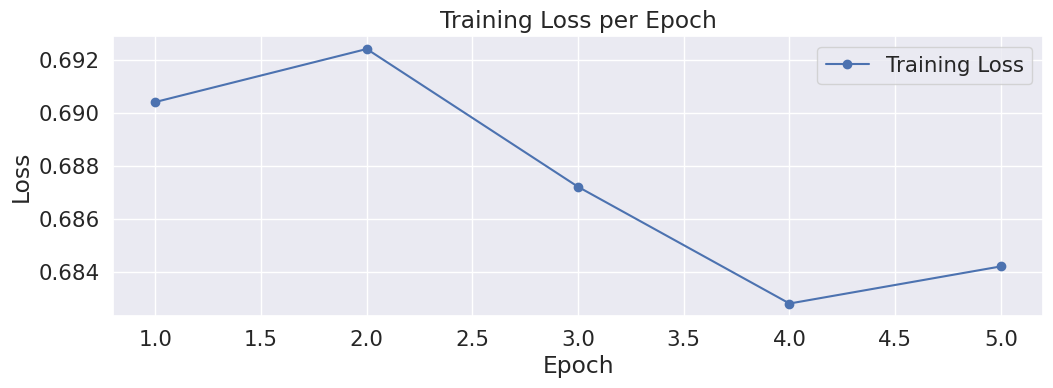

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# Loss Plot
plt.subplot(2, 1, 1)
plt.plot(epochs, train_losses, marker='o', label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss per Epoch')
plt.grid(True)
plt.legend()

In [ ]:
from collections import Counter
import numpy as np

# Get predictions
preds = trainer.predict(small_tokenized_dataset['val']).predictions
pred_labels = np.argmax(preds, axis=1)

# Count how many of each label are predicted
print("Predicted label counts:", Counter(pred_labels))

# Compare with ground truth
true_labels = small_tokenized_dataset['val']['label']
print("True label counts:", Counter(true_labels))

Predicted label counts: Counter({np.int64(0): 42, np.int64(1): 22})
True label counts: Counter({1: 32, 0: 32})


<Axes: >

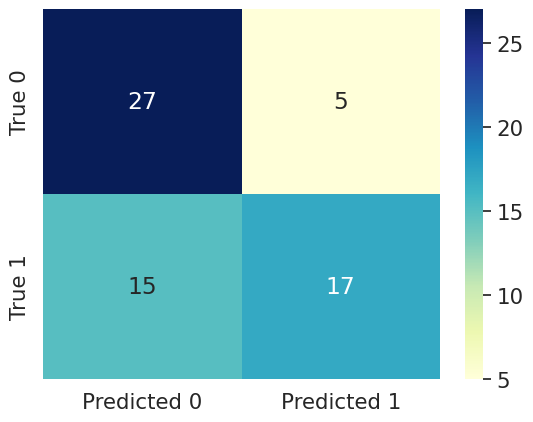

In [ ]:
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sn

conf_mat = metrics.confusion_matrix(true_labels, pred_labels)
df_cm = pd.DataFrame(conf_mat, ["True 0","True 1"], ["Predicted 0","Predicted 1"])

sn.set(font_scale=1.4)
sn.heatmap(df_cm, annot=True, fmt='d', cmap="YlGnBu")

In [ ]:
fine_tuned_model = AutoModelForSequenceClassification.from_pretrained("/content/drive/MyDrive/Colab Notebooks/sample_cl_trainer_more_samples_balanced/checkpoint-8") #choose the best one

In [ ]:
model_inputs = distilbert_tokenizer(test_review, return_tensors="pt")
prediction = torch.argmax(fine_tuned_model(**model_inputs).logits)

print(["Non-Spoiler", "Spoiler"][prediction])

NameError: name 'distilbert_tokenizer' is not defined

In [ ]:
trainer = Trainer(
    model=fine_tuned_model,
    args=arguments,
    train_dataset=small_tokenized_dataset['train'],
    eval_dataset=small_tokenized_dataset['test'], #change to test for final step
    tokenizer=distilbert_tokenizer,  # Optional, only if needed
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

NameError: name 'distilbert_tokenizer' is not defined

In [ ]:
model_inputs = roberta_tokenizer(test_review, return_tensors="pt")
prediction = torch.argmax(fine_tuned_model(**model_inputs).logits)

print(["Non-Spoiler", "Spoiler"][prediction])

Spoiler


In [ ]:
trainer = Trainer(
    model=fine_tuned_model,
    args=arguments,
    train_dataset=small_tokenized_dataset['train'],
    eval_dataset=small_tokenized_dataset['test'], #change to test for final step
    #tokenizer=roberta_tokenizer,  # Optional, only if needed
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.evaluate(eval_dataset=small_tokenized_dataset['test'])

{'eval_loss': 0.6912884712219238,
 'eval_model_preparation_time': 0.0037,
 'eval_accuracy': 0.5,
 'eval_precision': 0.5,
 'eval_recall': 0.875,
 'eval_f1': 0.6363636363636364,
 'eval_matthews_correlation': 0.0,
 'eval_runtime': 27.016,
 'eval_samples_per_second': 2.369,
 'eval_steps_per_second': 0.148}